# Análisis de errores de la rama fonémica. Mejor modelo: GRU

## Carga de datos y creación de DF de resultados

In [31]:
import pickle
from pathlib import Path
import pandas as pd
import numpy as np

# ----------------------------
# Rutas
# ----------------------------
PKL_PATH_PHON = Path(r"\\wsl.localhost\Ubuntu\home\lucas\projects\nejm-brain-to-text\model_training\trained_models\baseline_rnn\checkpoint\val_metrics.pkl")
CSV_LM_PATH_PHON = Path(r"\\wsl.localhost\Ubuntu\home\lucas\projects\nejm-brain-to-text\data\t15_pretrained_rnn_baseline\baseline_rnn_val_predicted_sentences_20260413_130014.csv")

# ----------------------------
# Cargar pkl
# ----------------------------
with open(PKL_PATH_PHON, "rb") as f:
    val_metrics_phon = pickle.load(f)

print(type(val_metrics_phon))
print(val_metrics_phon.keys())
for k, v in val_metrics_phon.items():
    try:
        print(k, type(v), len(v) if hasattr(v, "__len__") else "sin len")
    except Exception:
        print(k, type(v))

<class 'dict'>
dict_keys(['logits', 'n_time_steps', 'decoded_seqs', 'true_seq', 'phone_seq_lens', 'transcription', 'losses', 'block_nums', 'trial_nums', 'day_indicies', 'day_PERs', 'avg_PER', 'avg_loss'])
logits <class 'list'> 41
n_time_steps <class 'list'> 41
decoded_seqs <class 'list'> 41
true_seq <class 'list'> 41
phone_seq_lens <class 'list'> 41
transcription <class 'list'> 41
losses <class 'list'> 82
block_nums <class 'list'> 41
trial_nums <class 'list'> 41
day_indicies <class 'list'> 41
day_PERs <class 'dict'> 41
avg_PER <class 'float'> sin len
avg_loss <class 'numpy.float64'> sin len


In [54]:
import numpy as np
import pandas as pd

LOGIT_PHONE_DEF = [
    "BLANK", "SIL",
    "AA", "AE", "AH", "AO", "AW",
    "AY", "B", "CH", "D", "DH",
    "EH", "ER", "EY", "F", "G",
    "HH", "IH", "IY", "JH", "K",
    "L", "M", "N", "NG", "OW",
    "OY", "P", "R", "S", "SH",
    "T", "TH", "UH", "UW", "V",
    "W", "Y", "Z", "ZH"
]

ID_TO_PHONE = {i: p for i, p in enumerate(LOGIT_PHONE_DEF)}


def ascii_array_to_text(x):
    if x is None:
        return ""
    if isinstance(x, str):
        return x
    if isinstance(x, (list, tuple, np.ndarray)):
        chars = []
        for v in x:
            try:
                iv = int(v)
            except Exception:
                continue
            if iv == 0:
                continue
            chars.append(chr(iv))
        return "".join(chars)
    return str(x)


def ids_to_phones(seq, id_to_phone=ID_TO_PHONE, remove_blank=False):
    if seq is None:
        return []
    phones = []
    for x in seq:
        try:
            p = id_to_phone[int(x)]
        except Exception:
            p = f"UNK_{x}"
        if remove_blank and p == "BLANK":
            continue
        phones.append(p)
    return phones


def flatten_val_metrics_phon(val_metrics_dict):
    rows = []

    n_batches = len(val_metrics_dict["transcription"])

    for b in range(n_batches):
        trans_batch = val_metrics_dict["transcription"][b]
        decoded_batch = val_metrics_dict["decoded_seqs"][b]
        true_seq_batch = val_metrics_dict["true_seq"][b]
        day_batch = val_metrics_dict.get("day_indicies", [None] * n_batches)[b]
        block_batch = val_metrics_dict.get("block_nums", [None] * n_batches)[b]
        trial_batch = val_metrics_dict.get("trial_nums", [None] * n_batches)[b]
        phone_len_batch = val_metrics_dict.get("phone_seq_lens", [None] * n_batches)[b]
        n_time_batch = val_metrics_dict.get("n_time_steps", [None] * n_batches)[b]

        batch_size = len(trans_batch)

        for i in range(batch_size):
            true_text_val = trans_batch[i] if i < len(trans_batch) else None
            true_text = ascii_array_to_text(true_text_val)

            decoded_seq = decoded_batch[i] if i < len(decoded_batch) else None
            true_seq = true_seq_batch[i] if i < len(true_seq_batch) else None

            phone_seq_len = int(phone_len_batch[i]) if phone_len_batch is not None and i < len(phone_len_batch) else None

            # Truncar la secuencia verdadera a la longitud real
            if true_seq is not None and phone_seq_len is not None:
                true_seq_trimmed = [int(x) for x in true_seq[:phone_seq_len]]
            else:
                true_seq_trimmed = [int(x) for x in true_seq] if true_seq is not None else []

            decoded_seq_list = [int(x) for x in decoded_seq] if decoded_seq is not None else []

            rows.append({
                "batch_idx": b,
                "sample_idx_in_batch": i,

                "true_text_val": true_text_val,
                "true_text": true_text,

                "decoded_seq": decoded_seq_list,
                "true_seq": true_seq_trimmed,

                "decoded_seq_phones": ids_to_phones(decoded_seq_list, remove_blank=False),
                "true_seq_phones": ids_to_phones(true_seq_trimmed, remove_blank=False),

                "day_index": int(day_batch[i]) if day_batch is not None and i < len(day_batch) else None,
                "block_num": int(block_batch[i]) if block_batch is not None and i < len(block_batch) else None,
                "trial_num": int(trial_batch[i]) if trial_batch is not None and i < len(trial_batch) else None,
                "phone_seq_len": phone_seq_len,
                "n_time_steps": int(n_time_batch[i]) if n_time_batch is not None and i < len(n_time_batch) else None,
            })

    return pd.DataFrame(rows)


df_val_phon = flatten_val_metrics_phon(val_metrics_phon)
print(df_val_phon.shape)
display(df_val_phon[[
    "true_text",
    "decoded_seq",
    "true_seq",
    "decoded_seq_phones",
    "true_seq_phones",
    "day_index",
    "block_num",
    "trial_num"
]].head())

(1426, 13)


,true_text,decoded_seq,true_seq,decoded_seq_phones,true_seq_phones,day_index,block_num,trial_num
0,You can see the code at this point as well.,"[37, 34, 40, 20, 2, 23, 40, 29, 18, 40, 10, 3,...","[37, 34, 40, 20, 2, 23, 40, 29, 18, 40, 10, 3,...","[W, UH, ZH, JH, AA, M, ZH, R, IH, ZH, D, AE, Z...","[W, UH, ZH, JH, AA, M, ZH, R, IH, ZH, D, AE, Z...",1,8,0
1,How does it keep the cost down?,"[16, 5, 40, 9, 3, 38, 31, 40, 17, 31, 40, 20, ...","[16, 5, 40, 9, 3, 38, 40, 17, 31, 40, 20, 18, ...","[G, AO, ZH, CH, AE, Y, SH, ZH, HH, SH, ZH, JH,...","[G, AO, ZH, CH, AE, Y, ZH, HH, SH, ZH, JH, IH,...",1,8,1
2,Not too controversial.,"[23, 1, 31, 40, 31, 34, 40, 1, 23, 14, 28, 3, ...","[23, 1, 31, 40, 31, 34, 40, 20, 1, 23, 31, 28,...","[M, SIL, SH, ZH, SH, UH, ZH, SIL, M, EY, P, AE...","[M, SIL, SH, ZH, SH, UH, ZH, JH, SIL, M, SH, P...",1,8,2
3,The jury and a judge work together on it.,"[10, 3, 40, 19, 33, 28, 18, 40, 3, 23, 9, 40, ...","[10, 3, 40, 19, 33, 28, 18, 40, 3, 23, 9, 40, ...","[D, AE, ZH, IY, TH, P, IH, ZH, AE, M, CH, ZH, ...","[D, AE, ZH, IY, TH, P, IH, ZH, AE, M, CH, ZH, ...",1,8,3
4,Were quite vocal about it.,"[36, 12, 40, 20, 36, 6, 31, 40, 14, 33, 20, 3,...","[36, 12, 40, 20, 36, 6, 31, 40, 35, 25, 20, 3,...","[V, EH, ZH, JH, V, AW, SH, ZH, EY, TH, JH, AE,...","[V, EH, ZH, JH, V, AW, SH, ZH, UW, NG, JH, AE,...",1,8,4


In [33]:
# Unir con CSV de resultados de LM
# Preparar índices globales
df_val_phon = df_val_phon.reset_index(drop=True).copy()
df_val_phon["global_id"] = np.arange(len(df_val_phon))

df_lm_phon = df_lm_phon.rename(columns={
    "id": "global_id",
    "text": "lm_pred_text"
}).copy()

df_phon = df_val_phon.merge(df_lm_phon, on="global_id", how="left")

print("Filas pkl:", len(df_val_phon))
print("Filas csv LM:", len(df_lm_phon))
print("Filas unidas:", len(df_phon))
print("Predicciones LM faltantes:", df_phon["lm_pred_text"].isna().sum())

display(df_phon[[
    "global_id", "true_text", "lm_pred_text",
    "day_index", "block_num", "trial_num"
]].head())

Filas pkl: 1426
Filas csv LM: 1426
Filas unidas: 1426
Predicciones LM faltantes: 0


,global_id,true_text,lm_pred_text,day_index,block_num,trial_num
0,0,You can see the code at this point as well.,you can sci the code at this point as will,1,8,0
1,1,How does it keep the cost down?,how does it keep the cost down,1,8,1
2,2,Not too controversial.,not to controversial,1,8,2
3,3,The jury and a judge work together on it.,the jury and uh just work together on it,1,8,3
4,4,Were quite vocal about it.,were quite vocal about it,1,8,4


In [34]:
# Normalizar texto
import re

def normalize_text_for_error_analysis(text):
    if text is None:
        return ""
    text = str(text).lower().strip()
    text = text.replace(">", "")
    text = re.sub(r"[^\w\s]", "", text)
    text = " ".join(text.split())
    return text

df_phon["true_text_norm"] = df_phon["true_text"].apply(normalize_text_for_error_analysis)
df_phon["lm_pred_text_norm"] = df_phon["lm_pred_text"].apply(normalize_text_for_error_analysis)

display(df_phon[["true_text", "lm_pred_text", "true_text_norm", "lm_pred_text_norm"]].head())

,true_text,lm_pred_text,true_text_norm,lm_pred_text_norm
0,You can see the code at this point as well.,you can sci the code at this point as will,you can see the code at this point as well,you can sci the code at this point as will
1,How does it keep the cost down?,how does it keep the cost down,how does it keep the cost down,how does it keep the cost down
2,Not too controversial.,not to controversial,not too controversial,not to controversial
3,The jury and a judge work together on it.,the jury and uh just work together on it,the jury and a judge work together on it,the jury and uh just work together on it
4,Were quite vocal about it.,were quite vocal about it,were quite vocal about it,were quite vocal about it


In [35]:
# métricas de texto tras LM
def levenshtein_tokens(ref, hyp):
    n, m = len(ref), len(hyp)
    dp = [[0]*(m+1) for _ in range(n+1)]

    for i in range(n+1):
        dp[i][0] = i
    for j in range(m+1):
        dp[0][j] = j

    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if ref[i-1] == hyp[j-1] else 1
            dp[i][j] = min(
                dp[i-1][j] + 1,
                dp[i][j-1] + 1,
                dp[i-1][j-1] + cost
            )
    return dp[n][m]

def cer(ref, hyp):
    ref = list(normalize_text_for_error_analysis(ref))
    hyp = list(normalize_text_for_error_analysis(hyp))
    return levenshtein_tokens(ref, hyp) / max(len(ref), 1)

def wer(ref, hyp):
    ref = normalize_text_for_error_analysis(ref).split()
    hyp = normalize_text_for_error_analysis(hyp).split()
    return levenshtein_tokens(ref, hyp) / max(len(ref), 1)

df_phon["wer_lm"] = df_phon.apply(lambda r: wer(r["true_text"], r["lm_pred_text"]), axis=1)
df_phon["cer_lm"] = df_phon.apply(lambda r: cer(r["true_text"], r["lm_pred_text"]), axis=1)

display(df_phon[[
    "true_text", "lm_pred_text", "wer_lm", "cer_lm",
    "day_index", "block_num", "trial_num"
]].head())

,true_text,lm_pred_text,wer_lm,cer_lm,day_index,block_num,trial_num
0,You can see the code at this point as well.,you can sci the code at this point as will,0.200000,0.071429,1,8,0
1,How does it keep the cost down?,how does it keep the cost down,0.000000,0.000000,1,8,1
2,Not too controversial.,not to controversial,0.333333,0.047619,1,8,2
3,The jury and a judge work together on it.,the jury and uh just work together on it,0.222222,0.125000,1,8,3
4,Were quite vocal about it.,were quite vocal about it,0.000000,0.000000,1,8,4


### PER por muestra


In [36]:
def per_from_ids(true_seq, pred_seq):
    ref = [int(x) for x in true_seq] if true_seq is not None else []
    hyp = [int(x) for x in pred_seq] if pred_seq is not None else []
    return levenshtein_tokens(ref, hyp) / max(len(ref), 1)

df_phon["per"] = df_phon.apply(lambda r: per_from_ids(r["true_seq"], r["decoded_seq"]), axis=1)
df_phon["per"] = 1.0 - df_phon["per"]
display(df_phon[[
    "true_text", "per", "wer_lm", "cer_lm",
    "day_index", "block_num", "trial_num"
]].head())

,true_text,per,wer_lm,cer_lm,day_index,block_num,trial_num
0,You can see the code at this point as well.,0.070,0.200000,0.071429,1,8,0
1,How does it keep the cost down?,0.046,0.000000,0.000000,1,8,1
2,Not too controversial.,0.030,0.333333,0.047619,1,8,2
3,The jury and a judge work together on it.,0.066,0.222222,0.125000,1,8,3
4,Were quite vocal about it.,0.040,0.000000,0.000000,1,8,4


### Resumen inical


In [37]:
phon_summary = pd.Series({
    "n_samples": len(df_phon),
    "PER mean": df_phon["per"].mean(),
    "WER LM mean": df_phon["wer_lm"].mean(),
    "CER LM mean": df_phon["cer_lm"].mean(),
})

display(phon_summary)

n_samples      1426.000000
PER mean          0.050739
WER LM mean       0.197383
CER LM mean       0.110130
dtype: float64

### Coincidencia exacta tras LM

In [38]:
df_phon["exact_match_lm"] = (
    df_phon["true_text_norm"] == df_phon["lm_pred_text_norm"]
).astype(int)

print("Exact match LM:", df_phon["exact_match_lm"].mean())

Exact match LM: 0.34081346423562414


### Error por longitud

In [39]:
import pandas as pd
import numpy as np

# Bins por longitud en palabras
word_bins = [0, 4, 6, 8, 10, 100]
word_labels = ["1-4", "5-6", "7-8", "9-10", "11+"]
df_phon["true_word_len"] = df_phon["true_text_norm"].apply(lambda x: len(x.split()))
df_phon["true_char_len"] = df_phon["true_text_norm"].apply(len)


df_phon["word_len_bin"] = pd.cut(
    df_phon["true_word_len"],
    bins=word_bins,
    labels=word_labels,
    include_lowest=True
)

# Bins por longitud fonémica
phone_bins = [0, 10, 15, 20, 25, 100]
phone_labels = ["1-10", "11-15", "16-20", "21-25", "26+"]

df_phon["phone_len_bin"] = pd.cut(
    df_phon["phone_seq_len"],
    bins=phone_bins,
    labels=phone_labels,
    include_lowest=True
)

display(df_phon[[
    "true_text", "true_word_len", "phone_seq_len",
    "word_len_bin", "phone_len_bin",
    "per", "wer_lm"
]].head())

,true_text,true_word_len,phone_seq_len,word_len_bin,phone_len_bin,per,wer_lm
0,You can see the code at this point as well.,10,36,9-10,26+,0.070,0.200000
1,How does it keep the cost down?,7,26,7-8,26+,0.046,0.000000
2,Not too controversial.,3,19,1-4,16-20,0.030,0.333333
3,The jury and a judge work together on it.,9,35,9-10,26+,0.066,0.222222
4,Were quite vocal about it.,5,22,5-6,21-25,0.040,0.000000


In [40]:
length_summary_phon_words = (
    df_phon
    .groupby("word_len_bin", observed=False)
    .agg(
        n_samples=("true_text", "count"),
        mean_per=("per", "mean"),
        mean_wer_lm=("wer_lm", "mean"),
        mean_cer_lm=("cer_lm", "mean"),
    )
    .reset_index()
)

display(length_summary_phon_words)

,word_len_bin,n_samples,mean_per,mean_wer_lm,mean_cer_lm
0,1-4,229,0.029808,0.185590,0.101122
1,5-6,490,0.043931,0.179796,0.099325
2,7-8,429,0.056172,0.208084,0.116835
3,9-10,223,0.067919,0.218435,0.123296
4,11+,55,0.086509,0.234350,0.138212


In [41]:
length_summary_phon_phones = (
    df_phon
    .groupby("phone_len_bin", observed=False)
    .agg(
        n_samples=("true_text", "count"),
        mean_per=("per", "mean"),
        mean_wer_lm=("wer_lm", "mean"),
        mean_cer_lm=("cer_lm", "mean"),
    )
    .reset_index()
)

display(length_summary_phon_phones)

,phone_len_bin,n_samples,mean_per,mean_wer_lm,mean_cer_lm
0,1-10,3,0.016000,0.000000,0.000000
1,11-15,74,0.025000,0.167793,0.107208
2,16-20,197,0.032457,0.195431,0.106219
3,21-25,266,0.040955,0.162898,0.096203
4,26+,886,0.060009,0.211310,0.115797


### Error por longitud de frase

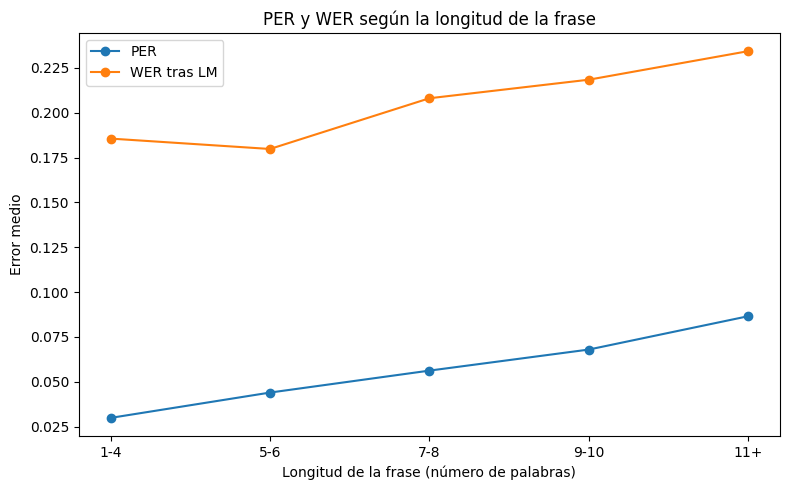

In [60]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(length_summary_phon_words["word_len_bin"].astype(str), length_summary_phon_words["mean_per"], marker="o", label="PER")
ax.plot(length_summary_phon_words["word_len_bin"].astype(str), length_summary_phon_words["mean_wer_lm"], marker="o", label="WER tras LM")
ax.set_xlabel("Longitud de la frase (número de palabras)")
ax.set_ylabel("Error medio")
ax.set_title("PER y WER según la longitud de la frase")
ax.legend()
plt.tight_layout()
plt.savefig("./img_fonemas/PER_WER_por_longitud_frase.png")
plt.show()

In [43]:
from scipy.stats import spearmanr

corr_word_per = spearmanr(df_phon["true_word_len"], df_phon["per"], nan_policy="omit")
corr_word_wer = spearmanr(df_phon["true_word_len"], df_phon["wer_lm"], nan_policy="omit")
corr_phone_per = spearmanr(df_phon["phone_seq_len"], df_phon["per"], nan_policy="omit")

print("Spearman longitud-palabras vs PER:", corr_word_per)
print("Spearman longitud-palabras vs WER:", corr_word_wer)
print("Spearman longitud-fonemas vs PER:", corr_phone_per)

Spearman longitud-palabras vs PER: SignificanceResult(statistic=np.float64(0.8555083646516671), pvalue=np.float64(0.0))
Spearman longitud-palabras vs WER: SignificanceResult(statistic=np.float64(0.12799850343241304), pvalue=np.float64(1.2392730874967935e-06))
Spearman longitud-fonemas vs PER: SignificanceResult(statistic=np.float64(0.9204189913603983), pvalue=np.float64(0.0))


### Error por sesión

In [44]:
session_summary_phon = (
    df_phon
    .groupby("day_index", dropna=False)
    .agg(
        n_samples=("true_text", "count"),
        mean_per=("per", "mean"),
        mean_wer_lm=("wer_lm", "mean"),
        mean_cer_lm=("cer_lm", "mean"),
        exact_match_lm=("exact_match_lm", "mean"),
    )
    .reset_index()
)

display(session_summary_phon.sort_values("mean_wer_lm"))

,day_index,n_samples,mean_per,mean_wer_lm,mean_cer_lm,exact_match_lm
23,24,25,0.057520,0.035476,0.016521,0.720000
22,23,50,0.055760,0.067897,0.026034,0.600000
21,22,34,0.051176,0.082505,0.039165,0.588235
26,27,23,0.055826,0.086511,0.046412,0.434783
5,6,49,0.047469,0.094817,0.048488,0.612245
33,37,46,0.058739,0.095923,0.049929,0.434783
19,20,20,0.048800,0.102937,0.050995,0.500000
17,18,15,0.038000,0.105079,0.057450,0.533333
18,19,25,0.050240,0.126286,0.067782,0.400000
2,3,48,0.048750,0.128648,0.070979,0.520833


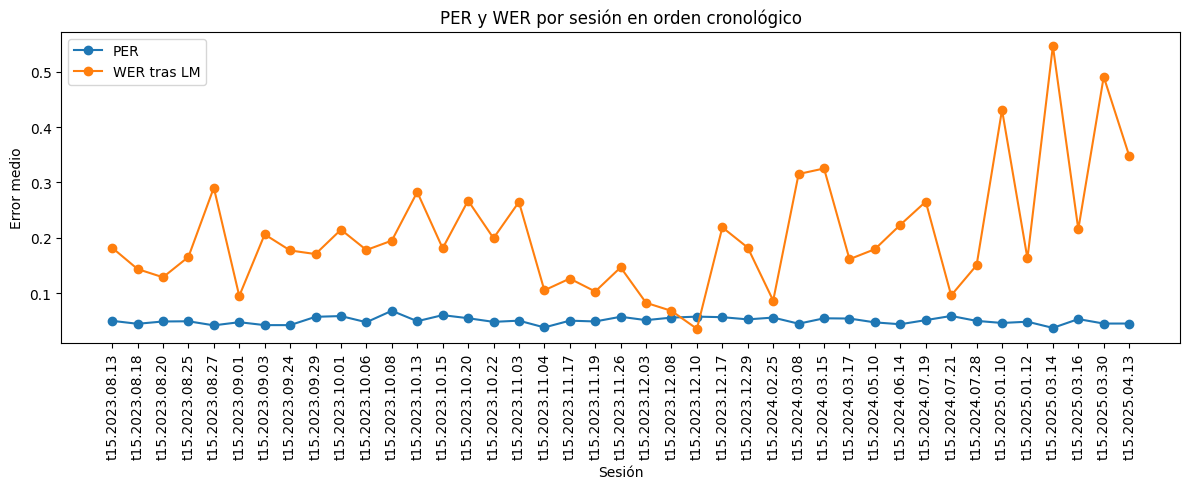

In [66]:
# ordenar por fecha
import pandas as pd
import matplotlib.pyplot as plt

# Lista de sesiones en el mismo orden en que fueron usadas en el entrenamiento
sessions = [
    "t15.2023.08.11",
    "t15.2023.08.13",
    "t15.2023.08.18",
    "t15.2023.08.20",
    "t15.2023.08.25",
    "t15.2023.08.27",
    "t15.2023.09.01",
    "t15.2023.09.03",
    "t15.2023.09.24",
    "t15.2023.09.29",
    "t15.2023.10.01",
    "t15.2023.10.06",
    "t15.2023.10.08",
    "t15.2023.10.13",
    "t15.2023.10.15",
    "t15.2023.10.20",
    "t15.2023.10.22",
    "t15.2023.11.03",
    "t15.2023.11.04",
    "t15.2023.11.17",
    "t15.2023.11.19",
    "t15.2023.11.26",
    "t15.2023.12.03",
    "t15.2023.12.08",
    "t15.2023.12.10",
    "t15.2023.12.17",
    "t15.2023.12.29",
    "t15.2024.02.25",
    "t15.2024.03.03",
    "t15.2024.03.08",
    "t15.2024.03.15",
    "t15.2024.03.17",
    "t15.2024.04.25",
    "t15.2024.04.28",
    "t15.2024.05.10",
    "t15.2024.06.14",
    "t15.2024.07.19",
    "t15.2024.07.21",
    "t15.2024.07.28",
    "t15.2025.01.10",
    "t15.2025.01.12",
    "t15.2025.03.14",
    "t15.2025.03.16",
    "t15.2025.03.30",
    "t15.2025.04.13",
]

# Si day_index empieza en 0:
day_to_session = {i: s for i, s in enumerate(sessions)}

# Si day_index empieza en 1, usa esta en su lugar:
# day_to_session = {i + 1: s for i, s in enumerate(sessions)}

plot_df = session_summary_phon.copy()

plot_df["session_name"] = plot_df["day_index"].map(day_to_session)

# Extraer fecha desde "t15.2023.08.11" -> "2023-08-11"
plot_df["session_date"] = pd.to_datetime(
    plot_df["session_name"].str.extract(r"(\d{4}\.\d{2}\.\d{2})")[0],
    format="%Y.%m.%d"
)

# Ordenar cronológicamente
plot_df = plot_df.sort_values("session_date").copy()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(plot_df["session_name"], plot_df["mean_per"], marker="o", label="PER")
ax.plot(plot_df["session_name"], plot_df["mean_wer_lm"], marker="o", label="WER tras LM")

ax.set_xlabel("Sesión")
ax.set_ylabel("Error medio")
ax.set_title("PER y WER por sesión en orden cronológico")
ax.legend()

plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("./img_fonemas/PER_WER_por_sesion_cronologico.png")
plt.show()

### Ejemplos de frases

In [46]:
# Mejores ejemplos tras LM
best_examples_phon = (
    df_phon
    .sort_values(["wer_lm", "cer_lm", "per"])
    .loc[:, [
        "true_text", "lm_pred_text", "per", "wer_lm", "cer_lm",
        "day_index", "block_num", "trial_num"
    ]]
    .head(10)
    .copy()
)

display(best_examples_phon)

,true_text,lm_pred_text,per,wer_lm,cer_lm,day_index,block_num,trial_num
1234,Of course.,of course,0.012,0.0,0.0,38,7,5
50,House robberies.,house robberies,0.018,0.0,0.0,2,6,15
290,Join the gang.,join the gang,0.018,0.0,0.0,8,9,15
461,Healthy vision.,healthy vision,0.018,0.0,0.0,13,5,17
631,How are you?,how are you,0.018,0.0,0.0,18,4,6
1113,It is fine.,it is fine,0.018,0.0,0.0,36,9,4
257,It's a nightmare.,its a nightmare,0.020,0.0,0.0,7,9,1
994,She can do it.,she can do it,0.020,0.0,0.0,30,9,5
279,Go over there.,go over there,0.022,0.0,0.0,8,9,4
298,All the money.,all the money,0.022,0.0,0.0,8,9,23


In [47]:
# Peores ejemplos tras LM
worst_examples_phon = (
    df_phon
    .sort_values(["wer_lm", "cer_lm", "per"], ascending=False)
    .loc[:, [
        "true_text", "lm_pred_text", "per", "wer_lm", "cer_lm",
        "day_index", "block_num", "trial_num"
    ]]
    .head(10)
    .copy()
)

display(worst_examples_phon)

,true_text,lm_pred_text,per,wer_lm,cer_lm,day_index,block_num,trial_num
1332,Not too long ago.,matt to slugger,0.020,1.0,0.687500,41,4,9
1139,I love eating pecan pie.,live ending performed by,0.034,1.0,0.652174,36,10,4
1323,I hope everything works out up there.,if easing news in own their,0.030,1.0,0.638889,41,4,0
1420,There's no deductions.,theirs tall tension,0.030,1.0,0.600000,44,8,19
1395,She doesn't work.,dozen walk,0.022,1.0,0.600000,43,13,19
242,Zoology department.,hewlett depart,0.014,1.0,0.555556,7,8,11
996,I couldn't understand.,wooden underside,0.026,1.0,0.550000,30,9,7
1324,Are you pleased with this decision?,leaves this is incision,0.022,1.0,0.529412,41,4,1
471,run bargains hopeless persists meals,gun bothers endless percent mills,0.042,1.0,0.472222,13,6,2
9,Woodworking mastery.,what working mastery,0.024,1.0,0.210526,1,8,9


In [48]:
# Casos con buen PER pero peor WER
interesting_examples_phon = (
    df_phon
    .sort_values(["per", "wer_lm"], ascending=[True, False])
    .loc[:, [
        "true_text", "lm_pred_text", "per", "wer_lm", "cer_lm",
        "day_index", "block_num", "trial_num"
    ]]
    .head(15)
    .copy()
)

display(interesting_examples_phon)

,true_text,lm_pred_text,per,wer_lm,cer_lm,day_index,block_num,trial_num
1234,Of course.,of course,0.012,0.000000,0.000000,38,7,5
242,Zoology department.,hewlett depart,0.014,1.000000,0.555556,7,8,11
1329,That is horrible.,that is overtake,0.014,0.333333,0.375000,41,4,6
26,Employee controller.,employee control,0.016,0.500000,0.157895,1,9,6
1109,Perhaps not in Dallas.,because what in dollars,0.018,0.750000,0.476190,35,12,23
1127,The door bell rang.,the store bail why,0.018,0.750000,0.500000,36,9,18
1379,It's a nice place.,its guys plays,0.018,0.750000,0.500000,43,13,3
1341,That is horrible.,that is caterpillar,0.018,0.333333,0.500000,41,6,6
50,House robberies.,house robberies,0.018,0.000000,0.000000,2,6,15
290,Join the gang.,join the gang,0.018,0.000000,0.000000,8,9,15


## Análsis fonémico

In [58]:
from collections import Counter

all_true_phones = []
all_pred_phones = []

for seq in df_val_phon["true_seq_phones"]:
    all_true_phones.extend(seq)

for seq in df_val_phon["decoded_seq_phones"]:
    all_pred_phones.extend(seq)

true_phone_freq = Counter(all_true_phones)
pred_phone_freq = Counter(all_pred_phones)

df_true_phone_freq = (
    pd.DataFrame({
        "phone": list(true_phone_freq.keys()),
        "true_count": list(true_phone_freq.values()),
        "pred_count": [pred_phone_freq.get(p, 0) for p in true_phone_freq.keys()]
    })
    .sort_values("true_count", ascending=False)
    .reset_index(drop=True)
)

display(df_true_phone_freq.head(20))

,phone,true_count,pred_count
0,ZH,9445,9436
1,AE,2705,2741
2,SH,2458,2545
3,HH,2069,2148
4,M,1939,1797
5,R,1588,1539
6,P,1451,1375
7,K,1281,1271
8,CH,1274,1289
9,IH,1162,1142


In [61]:
# Sustituciones fonémicas más frecuentes

def levenshtein_alignment(ref_tokens, hyp_tokens):
    n, m = len(ref_tokens), len(hyp_tokens)
    dp = [[0] * (m + 1) for _ in range(n + 1)]
    back = [[None] * (m + 1) for _ in range(n + 1)]

    for i in range(n + 1):
        dp[i][0] = i
        if i > 0:
            back[i][0] = "del"
    for j in range(m + 1):
        dp[0][j] = j
        if j > 0:
            back[0][j] = "ins"

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if ref_tokens[i - 1] == hyp_tokens[j - 1]:
                dp[i][j] = dp[i - 1][j - 1]
                back[i][j] = "ok"
            else:
                sub = dp[i - 1][j - 1] + 1
                dele = dp[i - 1][j] + 1
                ins = dp[i][j - 1] + 1
                best = min(sub, dele, ins)
                dp[i][j] = best

                if best == sub:
                    back[i][j] = "sub"
                elif best == dele:
                    back[i][j] = "del"
                else:
                    back[i][j] = "ins"

    i, j = n, m
    alignment = []

    while i > 0 or j > 0:
        op = back[i][j]
        if op == "ok":
            alignment.append(("ok", ref_tokens[i - 1], hyp_tokens[j - 1]))
            i -= 1
            j -= 1
        elif op == "sub":
            alignment.append(("sub", ref_tokens[i - 1], hyp_tokens[j - 1]))
            i -= 1
            j -= 1
        elif op == "del":
            alignment.append(("del", ref_tokens[i - 1], None))
            i -= 1
        elif op == "ins":
            alignment.append(("ins", None, hyp_tokens[j - 1]))
            j -= 1
        else:
            break

    alignment.reverse()
    return alignment


phone_sub_rows = []

for idx, row in df_val_phon.iterrows():
    ref_seq = row["true_seq_phones"]
    hyp_seq = row["decoded_seq_phones"]

    alignment = levenshtein_alignment(ref_seq, hyp_seq)

    for op, ref_tok, hyp_tok in alignment:
        if op == "sub":
            phone_sub_rows.append({
                "row_idx": idx,
                "ref_phone": ref_tok,
                "hyp_phone": hyp_tok,
            })

df_phone_subs = pd.DataFrame(phone_sub_rows)

phone_confusions = (
    df_phone_subs
    .groupby(["ref_phone", "hyp_phone"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

display(phone_confusions.head(20))

,ref_phone,hyp_phone,count
0,CH,SH,127
1,SH,CH,90
2,R,Y,70
3,AE,HH,70
4,Y,R,58
5,HH,AE,55
6,M,CH,47
7,AE,EH,45
8,DH,HH,45
9,IH,HH,43


In [62]:
from collections import Counter
import pandas as pd

# Frecuencia de fonemas en referencia
all_true_phones = []
for seq in df_val_phon["true_seq_phones"]:
    all_true_phones.extend(seq)

true_phone_freq = Counter(all_true_phones)

df_true_phone_freq = (
    pd.DataFrame({
        "ref_phone": list(true_phone_freq.keys()),
        "true_count": list(true_phone_freq.values())
    })
    .sort_values("true_count", ascending=False)
    .reset_index(drop=True)
)

display(df_true_phone_freq.head(20))

# Número de sustituciones por fonema de referencia
phone_sub_ref_counts = (
    df_phone_subs
    .groupby("ref_phone")
    .size()
    .reset_index(name="n_substitutions")
)

# Unir y normalizar
df_phone_error = df_true_phone_freq.merge(phone_sub_ref_counts, on="ref_phone", how="left")
df_phone_error["n_substitutions"] = df_phone_error["n_substitutions"].fillna(0).astype(int)
df_phone_error["substitution_rate"] = df_phone_error["n_substitutions"] / df_phone_error["true_count"]

df_phone_error = df_phone_error.sort_values("substitution_rate", ascending=False).reset_index(drop=True)

display(df_phone_error.head(20))

,ref_phone,true_count
0,ZH,9445
1,AE,2705
2,SH,2458
3,HH,2069
4,M,1939
5,R,1588
6,P,1451
7,K,1281
8,CH,1274
9,IH,1162


,ref_phone,true_count,n_substitutions,substitution_rate
0,F,364,84,0.230769
1,B,167,38,0.227545
2,IY,187,42,0.224599
3,TH,192,43,0.223958
4,DH,868,193,0.222350
5,NG,454,97,0.213656
6,S,176,36,0.204545
7,ER,525,105,0.200000
8,SIL,661,113,0.170953
9,AA,772,127,0.164508


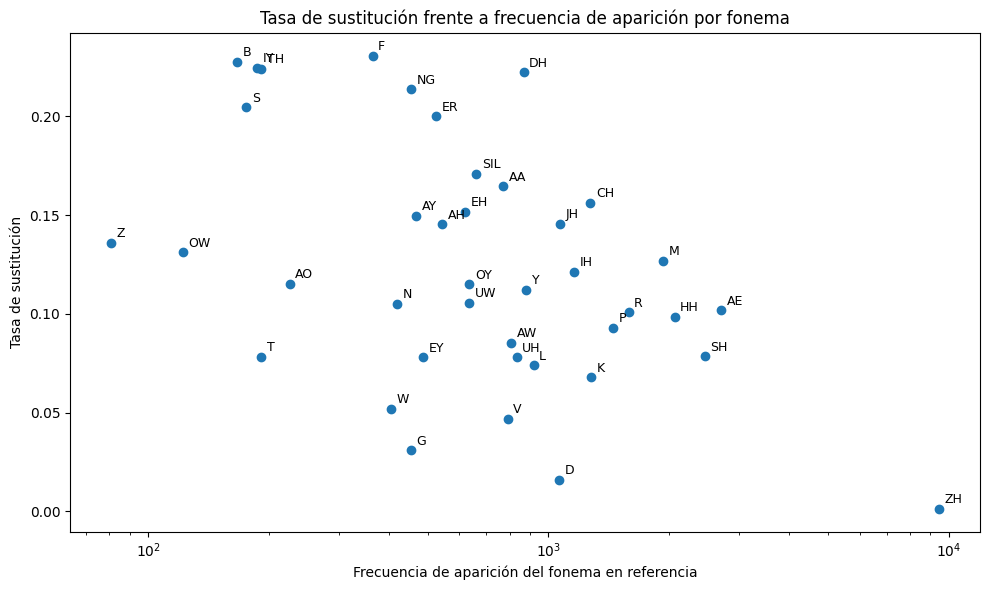

In [67]:
import matplotlib.pyplot as plt

plot_df = df_phone_error.copy()

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    plot_df["true_count"],
    plot_df["substitution_rate"]
)

# Etiquetar todos los fonemas
for _, row in plot_df.iterrows():
    ax.annotate(
        row["ref_phone"],
        (row["true_count"], row["substitution_rate"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=9
    )

ax.set_xscale("log")
ax.set_xlabel("Frecuencia de aparición del fonema en referencia")
ax.set_ylabel("Tasa de sustitución")
ax.set_title("Tasa de sustitución frente a frecuencia de aparición por fonema")

plt.tight_layout()
plt.savefig("./img_fonemas/tasa_error_vs_frecuencia_fonema.png", dpi=300)
plt.show()

In [69]:
corr_pearson = plot_df["true_count"].corr(plot_df["substitution_rate"], method="pearson")
corr_spearman = plot_df["true_count"].corr(plot_df["substitution_rate"], method="spearman")

print("Correlación Pearson:", corr_pearson)
print("Correlación Spearman:", corr_spearman)

Correlación Pearson: -0.4319182067389829
Correlación Spearman: -0.43071582889617477


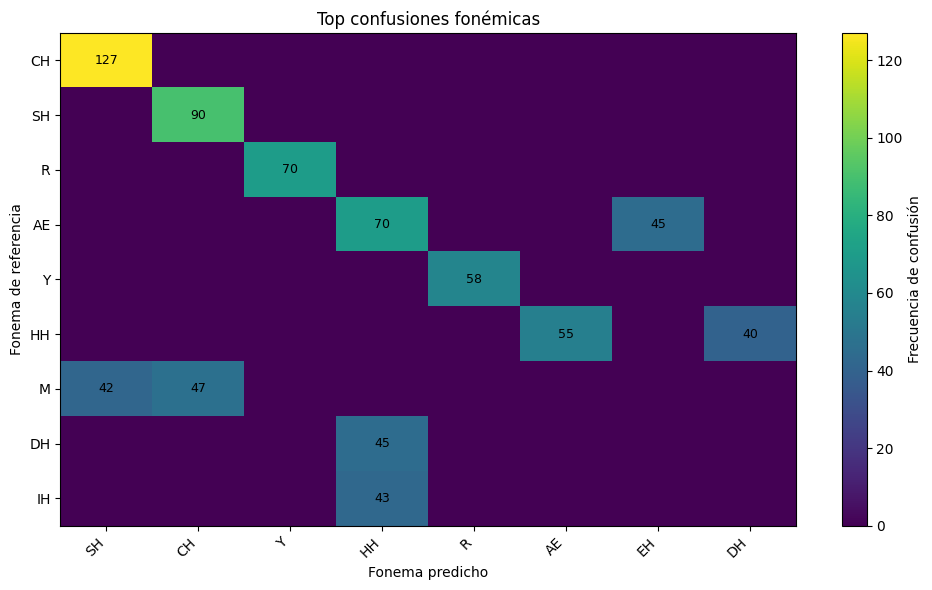

In [65]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_top_phone_confusion_heatmap(confusions_df, top_n=12, title="Top confusiones fonémicas"):
    top_df = confusions_df.head(top_n).copy()

    ref_phones = list(top_df["ref_phone"].unique())
    hyp_phones = list(top_df["hyp_phone"].unique())

    mat = pd.DataFrame(
        0,
        index=ref_phones,
        columns=hyp_phones,
        dtype=int
    )

    for _, row in top_df.iterrows():
        mat.loc[row["ref_phone"], row["hyp_phone"]] = row["count"]

    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(mat.values, aspect="auto", interpolation="nearest")

    ax.set_xticks(np.arange(len(mat.columns)))
    ax.set_yticks(np.arange(len(mat.index)))
    ax.set_xticklabels(mat.columns, rotation=45, ha="right")
    ax.set_yticklabels(mat.index)

    ax.set_xlabel("Fonema predicho")
    ax.set_ylabel("Fonema de referencia")
    ax.set_title(title)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.iloc[i, j]
            if val != 0:
                ax.text(j, i, str(val), ha="center", va="center", fontsize=9)

    fig.colorbar(im, ax=ax, label="Frecuencia de confusión")
    plt.tight_layout()
    plt.savefig("./img_fonemas/CM_fonemas.png")
    plt.show()

    return mat

mat_phone = plot_top_phone_confusion_heatmap(
    phone_confusions,
    top_n=12,
    title="Top confusiones fonémicas"
)